# Week 4 — Supervised Learning: Customer Churn Prediction

## Project: Customer Churn Prediction & Segmentation

### Objective
Build a supervised machine learning classification model to predict whether a customer is likely to churn based on their demographic, service, contract, tenure, and billing information.

### Dataset
IBM Telco Customer Churn Dataset

### Target Variable
Churn
- No → Customer stays
- Yes → Customer churns

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("telco_customer_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Separate features and target variable

X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [3]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [6]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 19)
Testing features: (1409, 19)
Training target: (5634,)
Testing target: (1409,)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create the Logistic Regression pipeline

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [8]:
# Train the Logistic Regression model

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [10]:
# Make predictions on the test data

y_pred = logistic_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 1409


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Yes')
recall = recall_score(y_test, y_pred, pos_label='Yes')
f1 = f1_score(y_test, y_pred, pos_label='Yes')

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-Score : 0.604


In [12]:
from sklearn.metrics import confusion_matrix

# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred, labels=['No', 'Yes'])

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[926 109]
 [165 209]]


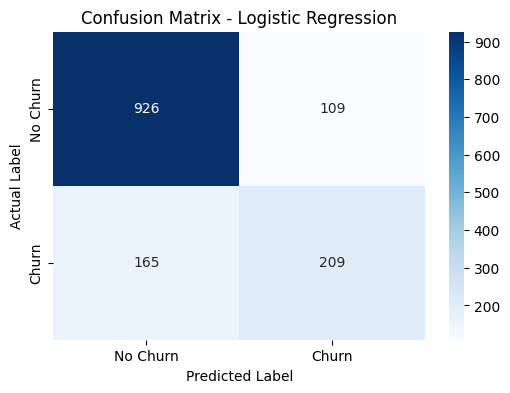

In [14]:
# Visualize the confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [15]:
# Generate a detailed classification report

from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [16]:
from sklearn.metrics import roc_auc_score

# Generate churn probabilities

y_proba = logistic_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC

roc_auc = roc_auc_score(
    (y_test == 'Yes').astype(int),
    y_proba
)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.8421


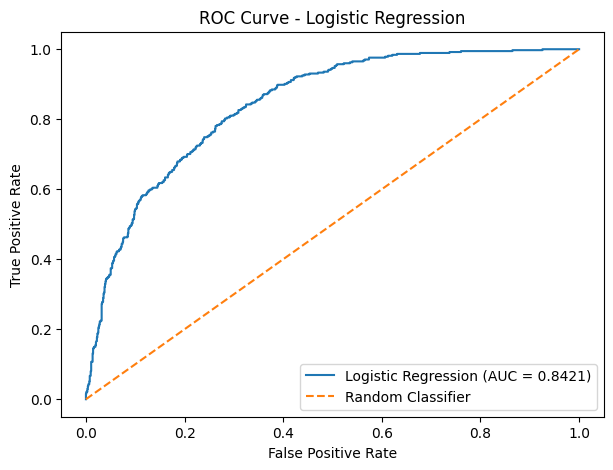

In [17]:
from sklearn.metrics import roc_curve

# Calculate ROC curve values

y_test_binary = (y_test == 'Yes').astype(int)

fpr, tpr, thresholds = roc_curve(y_test_binary, y_proba)

# Plot ROC curve

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

In [18]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation

cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation accuracy scores:")
print(cv_scores)

print("\nMean cross-validation accuracy:",
      round(cv_scores.mean(), 4))

print("Standard deviation:",
      round(cv_scores.std(), 4))

Cross-validation accuracy scores:
[0.83052351 0.80212955 0.80567879 0.79148181 0.79129663]

Mean cross-validation accuracy: 0.8042
Standard deviation: 0.0143


In [19]:
# Interpret Logistic Regression feature coefficients

feature_names = logistic_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = logistic_model.named_steps['classifier'].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by coefficient to see the strongest positive and negative relationships
feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

print("Top features associated with higher churn probability:")
print(feature_importance.head(10))

print("\nTop features associated with lower churn probability:")
print(feature_importance.tail(10))

Top features associated with higher churn probability:
                                Feature  Coefficient
16     cat__InternetService_Fiber optic     0.634195
36         cat__Contract_Month-to-month     0.582883
3                     num__TotalCharges     0.536253
35             cat__StreamingMovies_Yes     0.200938
32                 cat__StreamingTV_Yes     0.200481
43  cat__PaymentMethod_Electronic check     0.197867
18               cat__OnlineSecurity_No     0.156279
27                  cat__TechSupport_No     0.131503
14               cat__MultipleLines_Yes     0.104649
0                    num__SeniorCitizen     0.053449

Top features associated with lower churn probability:
                                      Feature  Coefficient
19    cat__OnlineSecurity_No internet service    -0.300104
17                    cat__InternetService_No    -0.300104
31       cat__StreamingTV_No internet service    -0.300104
25  cat__DeviceProtection_No internet service    -0.300104
22      cat_

Strengths, Limitations and Possible Improvements
Strengths of the Logistic Regression Model

The Logistic Regression model provides a simple and interpretable approach for predicting customer churn. The model achieved an accuracy of 80.55% on the test dataset, with a ROC-AUC score of 0.8421, indicating good ability to distinguish between customers who churn and those who stay.

The model also provides feature coefficients that help understand how different customer characteristics are associated with churn predictions. For example, month-to-month contracts and fiber-optic internet service had positive coefficients, while longer tenure and two-year contracts had negative coefficients. This makes Logistic Regression useful when interpretability is important.

The preprocessing steps were incorporated into a pipeline, ensuring that numerical features were scaled and categorical features were one-hot encoded consistently during training and prediction.

Limitations

One important limitation is class imbalance in the dataset. There are significantly more customers who did not churn than customers who churned. As a result, the model performs better at identifying non-churn customers than churned customers. The churn class had a recall of 55.88%, meaning some actual churn customers were not identified.

Another limitation is that the model uses the default 0.5 probability threshold for classification. Changing this threshold could potentially increase recall if identifying more potential churners is more important.

Logistic Regression also assumes a relatively linear relationship between the input features and the log-odds of the outcome. Complex non-linear relationships between customer characteristics may therefore not be fully captured.

Possible Improvements

Several improvements can be explored in future versions:

Handle class imbalance: Techniques such as class weighting or resampling can be investigated to give greater importance to the minority churn class.
Threshold adjustment: Instead of automatically classifying customers as churners when their predicted probability is ≥ 0.5, different probability thresholds can be evaluated to find a suitable balance between precision and recall.
Regularization: Logistic Regression supports L1 and L2 regularization. Tuning the regularization strength can help control model complexity and reduce the effect of less useful features.
Feature engineering: Additional meaningful features could be created from existing customer information, such as tenure groups, average monthly spending, service combinations, or indicators representing customer engagement. These features could provide the model with additional information for predicting churn.
Further validation: Additional experiments with different preprocessing and parameter settings can be performed while maintaining appropriate validation procedures to avoid data leakage.
Overall Conclusion

The Logistic Regression model provides a strong baseline for the customer churn prediction task. Its 80.55% test accuracy and 0.8421 ROC-AUC demonstrate useful predictive performance, while its coefficients provide interpretability. However, the relatively lower recall for the churn class indicates that further work is needed if the primary objective is to identify as many potential churn customers as possible.

## Week 4 — Final Conclusion

In Week 4, a Logistic Regression classification model was developed to predict customer churn using demographic, service, contract, tenure, and billing-related features. The dataset was divided into training and testing sets using an 80:20 stratified split, while numerical and categorical features were preprocessed using standardization and one-hot encoding.

The model achieved an accuracy of **80.55%**, precision of **65.72%**, recall of **55.88%**, and F1-score of **60.40%** on the test dataset. The model also achieved a **ROC-AUC score of 0.8421**, indicating good ability to distinguish between customers who churn and those who remain. Five-fold cross-validation produced a mean accuracy of **80.42%**, showing consistent performance across different training subsets.

The analysis of Logistic Regression coefficients provided additional insight into the features associated with the model's churn predictions. Overall, Week 4 successfully implemented the complete supervised learning workflow, from data preparation and model training to validation, evaluation, and interpretation.

Future improvements may include addressing class imbalance, adjusting the classification threshold, tuning regularization, and creating additional meaningful features.